## 1. Importing libraries

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

## 2. Loading Data

In [4]:
df = pd.read_csv("../data/raw/spam.csv", encoding="latin-1")
print(df.head())

     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  


## 3. Exploratory Data Analysis

In [5]:
print(f"Dataset shape: {df.shape}")
print(f"\nDataset column names: {df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n {df.isnull().sum()}")
print(f"\nFirst 5 rows: \n{df.head()}")

Dataset shape: (5572, 5)

Dataset column names: ['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']

Data types:
v1            object
v2            object
Unnamed: 2    object
Unnamed: 3    object
Unnamed: 4    object
dtype: object

Missing values:
 v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

First 5 rows: 
     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  


In [6]:
df = df.drop(columns=["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"])

In [7]:
df = df.rename(columns={"v1": "label", "v2": "sms-text"})
print(f"\nDataset column names: {df.columns.tolist()}")
print(f"Dataset shape: {df.shape}")
print(f"\nData types:\n{df.dtypes}")


Dataset column names: ['label', 'sms-text']
Dataset shape: (5572, 2)

Data types:
label       object
sms-text    object
dtype: object


In [8]:
print("Class distribution:")
print(df["label"].value_counts())
print("\nClass distribution percentage:")
print(df["label"].value_counts(normalize=True) * 100)
print("\n")

Class distribution:
ham     4825
spam     747
Name: label, dtype: int64

Class distribution percentage:
ham     86.593683
spam    13.406317
Name: label, dtype: float64




In [9]:
print("Sample Spam SMS-Message:")
print(df[df["label"] == "spam"]["sms-text"].iloc[0])
print("\n")
print("Sample Ham SMS-Message:")
print(df[df["label"] == "ham"]["sms-text"].iloc[2])


Sample Spam SMS-Message:
Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's


Sample Ham SMS-Message:
U dun say so early hor... U c already then say...


In [10]:
# Create length features 
df['char_count'] = df['sms-text'].str.len()
df['word_count'] = df['sms-text'].str.split().apply(len)

# Check stastistics by class
print(df.groupby('label').agg({'char_count': 'mean', 'word_count': 'mean'}))

       char_count  word_count
label                        
ham     71.023627   14.200622
spam   138.866131   23.851406


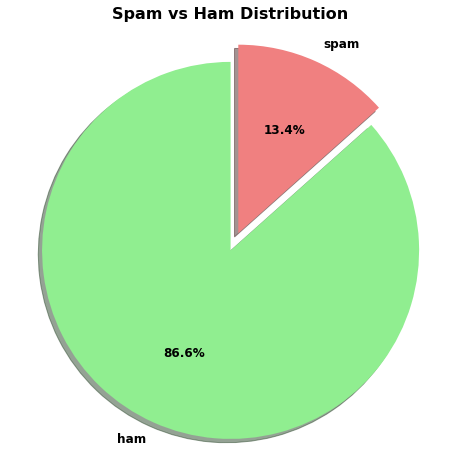

<Figure size 432x288 with 0 Axes>

In [11]:
# Get value counts
label_counts = df['label'].value_counts()

# Create pie chart
plt.figure(figsize=(8, 8))
colors = ['lightgreen', 'lightcoral']
explode = (0.05, 0.05)  # Slightly separate the slices

plt.pie(label_counts.values, 
        labels=label_counts.index, 
        autopct='%1.1f%%',
        startangle=90,
        colors=colors,
        explode=explode,
        shadow=True,
        textprops={'fontsize': 12, 'fontweight': 'bold'})

plt.title('Spam vs Ham Distribution', fontsize=16, fontweight='bold')
plt.axis('equal')  # Equal aspect ratio ensures circular pie
plt.show()
plt.savefig('../results/plots/spam_vs_ham_class_distribution.png')

In [12]:
spam_count = (df['label'] == 'spam').sum()
ham_count = (df['label'] == 'ham').sum()

# Calculate imbalance ratio
imbalance_ratio = ham_count / spam_count
print("="*50)
print("CLASS IMBALANCE ANALYSIS")
print("="*50)
print(f"Ham messages: {ham_count}")
print(f"Spam messages: {spam_count}")
print(f"Total messages: {len(df)}")
print(f"\nImbalance Ratio (Ham:Spam): {imbalance_ratio:.2f}:1")
print(f"This means there are {imbalance_ratio:.2f} ham messages for every 1 spam message")
print(f"Models trained on imbalanced data may perform poorly on spam detection")
print("="*50)

CLASS IMBALANCE ANALYSIS
Ham messages: 4825
Spam messages: 747
Total messages: 5572

Imbalance Ratio (Ham:Spam): 6.46:1
This means there are 6.46 ham messages for every 1 spam message
Models trained on imbalanced data may perform poorly on spam detection


In [13]:
spam_messages = df[df['label'] == 'spam']['sms-text']
ham_messages = df[df['label'] == 'ham']['sms-text']

combined_spam_message = ' '.join(spam_messages).lower()
combined_ham_message = ' '.join(ham_messages).lower()

print(f"\nCombined Spam Message:\n{combined_spam_message}")
print(f"\nCombined Ham Message:\n{combined_ham_message}")

spam_words = combined_spam_message.split()
ham_words = combined_ham_message.split()

spam_word_counts = Counter(spam_words)
ham_word_counts = Counter(ham_words)

spam_df = pd.DataFrame({
    'word': spam_word_counts.keys(),
    'count': spam_word_counts.values()
})

ham_df = pd.DataFrame({
    'word': ham_word_counts.keys(),
    'count': ham_word_counts.values()
})

spam_df = spam_df.sort_values(by='count', ascending=False)
ham_df = ham_df.sort_values(by='count', ascending=False)

print(f"\nTop 20 Spam Words:\n{spam_df.head(20)}")
print(f"\nTop 20 Ham Words:\n{ham_df.head(20)}")


Combined Spam Message:
free entry in 2 a wkly comp to win fa cup final tkts 21st may 2005. text fa to 87121 to receive entry question(std txt rate)t&c's apply 08452810075over18's freemsg hey there darling it's been 3 week's now and no word back! i'd like some fun you up for it still? tb ok! xxx std chgs to send, å£1.50 to rcv winner!! as a valued network customer you have been selected to receivea å£900 prize reward! to claim call 09061701461. claim code kl341. valid 12 hours only. had your mobile 11 months or more? u r entitled to update to the latest colour mobiles with camera for free! call the mobile update co free on 08002986030 six chances to win cash! from 100 to 20,000 pounds txt> csh11 and send to 87575. cost 150p/day, 6days, 16+ tsandcs apply reply hl 4 info urgent! you have won a 1 week free membership in our å£100,000 prize jackpot! txt the word: claim to no: 81010 t&c www.dbuk.net lccltd pobox 4403ldnw1a7rw18 xxxmobilemovieclub: to use your credit, click the wap link in t

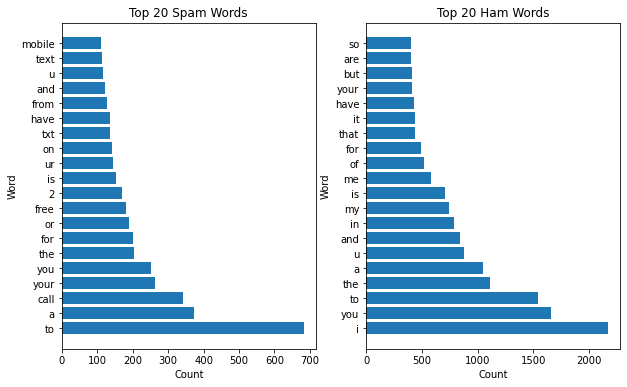

<Figure size 432x288 with 0 Axes>

In [14]:
plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
plt.barh(spam_df['word'][:20], spam_df['count'][:20])
plt.title('Top 20 Spam Words')
plt.xlabel('Count')
plt.ylabel('Word')
plt.subplot(1,2,2)
plt.barh(ham_df['word'][:20], ham_df['count'][:20:])
plt.title('Top 20 Ham Words')
plt.xlabel('Count')
plt.ylabel('Word')
plt.show()
plt.savefig('../results/plots/top_20_words.png')

We notice that the top words are not meaningful and they're mostly stop words. The only word that is meaningful is "free" in the spam messages but for now we really can't differentiate between spam and ham.

In [13]:
!pip install wordcloud
!pip install --upgrade pip
!pip install --upgrade Pillow

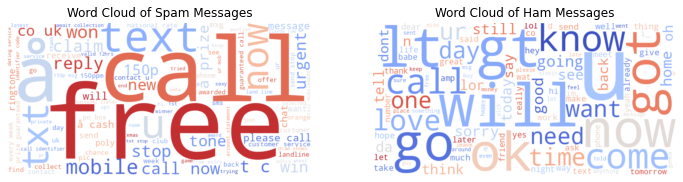

<Figure size 432x288 with 0 Axes>

In [15]:
from wordcloud import WordCloud

spam_word_cloud = WordCloud(width=800, height=400, background_color='white',max_words=100, colormap='coolwarm').generate(combined_spam_message)
ham_word_cloud = WordCloud(width=800, height=400, background_color='white',max_words=100, colormap='coolwarm').generate(combined_ham_message)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(spam_word_cloud, interpolation='bilinear')
plt.title('Word Cloud of Spam Messages')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(ham_word_cloud, interpolation='bilinear')
plt.title('Word Cloud of Ham Messages')
plt.axis('off')
plt.show()
plt.savefig('../results/plots/wordcloud.png')


In [16]:
# Special Character Analysis
df['has_url'] = df['sms-text'].str.contains('http|https|www', case=False).astype(int)
df['has_currency'] = df['sms-text'].str.contains('[$€£]', case=False).astype(int)
df['has_phone_number'] = df['sms-text'].str.contains(r'\d{10,}', regex=True).astype(int) # check for 10+ digits

print("Feature presence by class: \n")
print(df.groupby('label')[['has_url', 'has_currency', 'has_phone_number']].mean() * 100)

Feature presence by class: 

         has_url  has_currency  has_phone_number
label                                           
ham     0.062176      0.373057          0.020725
spam   14.323963     34.404284         54.216867


In [17]:
# N-gram Analysis
def get_top_ngrams(corpus, n=2, top_k=20):
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english')

    bag_of_words = vec.fit_transform(corpus)
    
    sum_words = bag_of_words.sum(axis=0) 
    
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]

    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

    return pd.DataFrame(words_freq[:top_k], columns=['ngram', 'Count'])


In [20]:
spam_ngram = get_top_ngrams(spam_messages, n=2, top_k=20)
ham_ngram = get_top_ngrams(ham_messages, n=2, top_k=20)

print("Top 20 N-grams in Spam Messages:")
print(spam_ngram)

print("\nTop 20 N-grams in Ham Messages:")
print(ham_ngram)

Top 20 N-grams in Spam Messages:
                ngram  Count
0              po box     24
1           1000 cash     23
2    prize guaranteed     22
3           send stop     20
4       national rate     20
5    selected receive     19
6    await collection     19
7       urgent mobile     18
8           land line     18
9    customer service     17
10        valid 12hrs     17
11           150p msg     17
12        prize claim     17
13         chance win     17
14         free entry     16
15  account statement     16
16    identifier code     16
17           txt stop     16
18           txt word     15
19     trying contact     15

Top 20 N-grams in Ham Messages:
           ngram  Count
0          lt gt    276
1       ll later     42
2       let know     40
3       sorry ll     39
4   good morning     32
5       don know     24
6     lt decimal     23
7     decimal gt     23
8       new year     23
9       pls send     22
10        ok lor     22
11    good night     19
12      just 

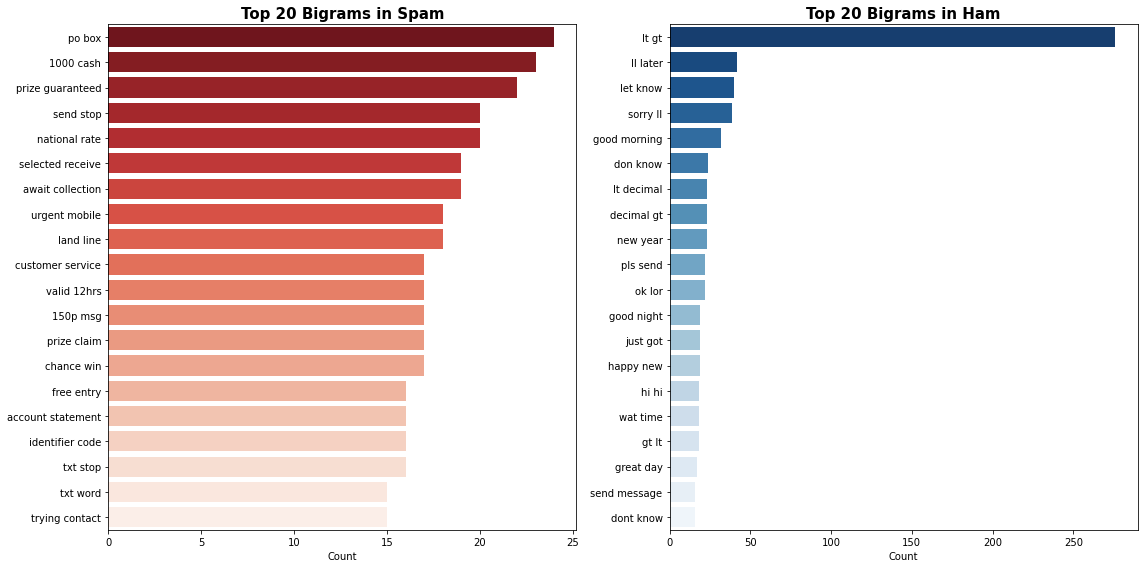

<Figure size 432x288 with 0 Axes>

In [27]:
def plot_ngrams(spam_ngrams, ham_ngrams, title_prefix="Bigrams"):
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    sns.barplot(x='Count', y='ngram', data=spam_ngram, ax=axes[0], palette='Reds_r')
    axes[0].set_title(f'Top 20 {title_prefix} in Spam', fontsize=15, fontweight='bold')
    axes[0].set_xlabel('Count')
    axes[0].set_ylabel('')

    sns.barplot(x='Count', y='ngram', data=ham_ngram, ax=axes[1], palette='Blues_r')
    axes[1].set_title(f'Top 20 {title_prefix} in Ham', fontsize=15, fontweight='bold')
    axes[1].set_xlabel('Count')
    axes[1].set_ylabel('')

    plt.tight_layout()
    plt.show()

plot_ngrams(spam_ngram, ham_ngram, title_prefix="Bigrams")
plt.savefig('../results/plots/bigrams.png')


## EDA Conclusion

Based on our exploratory analysis, we have identified several key patterns that distinguish spam from ham:

1. **Class Imbalance:** The dataset is highly imbalanced (87% Ham vs 13% Spam). We will need to address this during model training.
2. **Message Length:** Spam messages tend to be longer (avg 138 vs 71 characters).
3. **Keywords:** Spam is dominated by promotional words like "FREE", "call", "txt", "claim", "prize".
4. **Special Characters:** Spam has high usage of URLs, currency symbols, and phone numbers.
5. **N-grams:** Phrases like "prize claim" and "urgent mobile" are strong predictors.

### Next Steps:
- Implement a **Preprocessing Pipeline** (Stopword removal, Lemmatization).
- Create **Engineering Features** based on our findings.

## 4. Preprocessing Data

In [ ]:
import os
import sys
sys.path.append(os.path.abspath('..'))

In [65]:
import nltk
from nltk import pos_tag
from nltk.tokenize import word_tokenize
from nltk import ne_chunk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('maxent_ne_chunker', quiet=True)
nltk.download('words', quiet=True)

True

In [51]:
from src.preprocessing import clean_text, tokenize, remove_stopwords, lemmatize

def preprocess_pipeline(text):
    text = clean_text(text)
    tokens = tokenize(text)
    tokens = remove_stopwords(tokens)
    tokens = lemmatize(tokens)
    return " ".join(tokens)


print("Preprocessing data... this may take a moment.")
df['processed_text'] = df['sms-text'].apply(preprocess_pipeline)
print("Done!")
# 6. Show the Difference
print("\nSample Comparison:")
print(df[['sms-text', 'processed_text']].head())

Preprocessing data... this may take a moment.
Done!

Sample Comparison:
                                            sms-text  \
0  Go until jurong point, crazy.. Available only ...   
1                      Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup fina...   
3  U dun say so early hor... U c already then say...   
4  Nah I don't think he goes to usf, he lives aro...   

                                      processed_text  
0  go jurong point crazy available bugis n great ...  
1                            ok lar joking wif u oni  
2  free entry wkly comp win fa cup final tkts st ...  
3                u dun say early hor u c already say  
4           nah dont think go usf life around though  


## 5. Linguistic Analysis

In [66]:
def get_pos_tags(text):
    tokens = word_tokenize(text)
    tagged_tokens = pos_tag(tokens)
    tags = [tag for word, tag in tagged_tokens]
    return tags

df['pos_tags'] = df['sms-text'].apply(get_pos_tags)
print(df[['sms-text','pos_tags']].head())


                                            sms-text  \
0  Go until jurong point, crazy.. Available only ...   
1                      Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup fina...   
3  U dun say so early hor... U c already then say...   
4  Nah I don't think he goes to usf, he lives aro...   

                                            pos_tags  
0  [NNP, IN, JJ, NN, ,, JJ, NN, NNP, RB, IN, NN, ...  
1                  [NNP, NN, :, NNP, WRB, JJ, NN, :]  
2  [JJ, NN, IN, CD, DT, JJ, NN, TO, VB, NNP, NNP,...  
3  [JJ, NNS, VBP, RB, JJ, NN, :, NNP, VBP, RB, RB...  
4  [NNP, PRP, VBP, RB, VB, PRP, VBZ, TO, VB, ,, P...  


### (POS) Tagging Analysis

We have tagged each word with its grammatical role using NLTK's `averaged_perceptron_tagger`. The common tags include:

- **NN / NNS / NNP:** Noun (singular/plural) - *e.g., "prize", "winner"*
- **VB / VBP / VBG:** Verb (base/present/gerund) - *e.g., "call", "win", "running"*
- **JJ:** Adjective - *e.g., "free", "urgent"*
- **PRP:** Pronoun - *e.g., "you", "me"*
- **CD:** Cardinal Number - *e.g., "1000", "50"*

**Goal:**
We can now analyze if **Spam** messages rely more heavily on specific parts of speech (like Verbs and Numbers) compared to **Ham** messages (which might use more Pronouns and Nouns).

In [69]:
def extract_entities(text):
    entities = []
    tags = pos_tag(word_tokenize(text))
    tree = ne_chunk(tags)

    for chunk in tree:
        if hasattr(chunk, 'label'):
            entity_name = ' '.join(c[0] for c in chunk)
            entity_label = chunk.label()
            entities.append((entity_name, entity_label))
    return entities

In [70]:
print("Extracting entities... (Please wait)")
df['entities'] = df['sms-text'].apply(extract_entities)
print("Done!")

spam_entities = [ent for sublist in df[df['label'] == 'spam']['entities'] for ent in sublist]
ham_entities = [ent for sublist in df[df['label'] == 'ham']['entities'] for ent in sublist]

print("\nTop 10 Entities in SPAM :")
print(Counter(spam_entities).most_common(10))
print("\nTop 10 Entities in HAM :")
print(Counter(ham_entities).most_common(10))

Extracting entities... (Please wait)
Done!

Top 10 Entities in SPAM :
[(('URGENT', 'ORGANIZATION'), 34), (('FREE', 'ORGANIZATION'), 31), (('GUARANTEED', 'ORGANIZATION'), 22), (('Text', 'PERSON'), 18), (('Txt', 'PERSON'), 17), (('Free', 'GPE'), 16), (('SAE', 'ORGANIZATION'), 16), (('CASH', 'ORGANIZATION'), 12), (('Orange', 'GPE'), 12), (('UK', 'ORGANIZATION'), 11)]

Top 10 Entities in HAM :
[(('Sorry', 'PERSON'), 111), (('Ok', 'GPE'), 56), (('Good', 'GPE'), 39), (('Hi', 'GPE'), 34), (('Yup', 'GPE'), 28), (('Haha', 'GPE'), 25), (('Hey', 'GPE'), 24), (('Hello', 'GPE'), 23), (('DECIMAL', 'ORGANIZATION'), 23), (('Aight', 'GPE'), 21)]


## 6. Feature Engineering

## 7. Model Training

## 8. Model Evaluation

## 9. Model Export